# 00 - See the real data | شاهد البيانات الحقيقية

This notebook only displays one real science frame and one dark frame. It does not claim a transit result. Run each cell with **Shift+Enter**.

هذا الدفتر يعرض صورة سماء حقيقية وصورة معايرة فقط. لا يدعي أنه اكتشف العبور. شغّل كل خلية باستخدام **Shift+Enter**.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.stats import SigmaClip
from photutils.background import Background2D, MedianBackground

project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent

science_dir = project_root / 'database' / 'observations' / '2026-08-08' / 'WASP-10' / 'session_01'
dark_dir = project_root / 'database' / 'calibration' / '2026-08-08'
science_path = sorted(science_dir.glob('*.fits'))[0]
dark_path = sorted(dark_dir.glob('*.fits'))[0]
science_path, dark_path

C:\Users\iix_m\miniconda3\envs\exoplanet-poc\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(WindowsPath('C:/Users/iix_m/Downloads/hack4dev/database/observations/2026-08-08/WASP-10/session_01/WASP-10260808054017.fits'),
 WindowsPath('C:/Users/iix_m/Downloads/hack4dev/database/calibration/2026-08-08/Dark-C-260808123758.fits'))

In [2]:
science = fits.getdata(science_path).astype(float)
science_header = fits.getheader(science_path)
dark = fits.getdata(dark_path).astype(float)

print('Science file:', science_path.name)
print('Host star:', science_header.get('OBJECT'))
print('Image shape:', science.shape)
print('Exposure:', science_header.get('EXPTIME'), 'seconds')
print('Filter:', science_header.get('FILTER'))
print('Observation time:', science_header.get('DATE-OBS'))

Science file: WASP-10260808054017.fits
Host star: WASP-10
Image shape: (500, 650)
Exposure: 60.0 seconds
Filter: Clear
Observation time: 2026-08-07T22:40:17.063-0700


## What are you looking at? | ماذا ترى؟

- **WASP-10** is the host star. The planet is **WASP-10 b**.
- The planet is not visible. We infer it later from a small drop in the host star's measured brightness.
- Most bright points in the science image are stars. We have not identified which point is WASP-10 yet.
- The dark frame is captured with the shutter closed. It shows sensor glow, hot pixels, and electronic noise, not the sky.
- The enhanced view removes the broad background pattern for easier viewing. This is not yet the final scientific calibration.

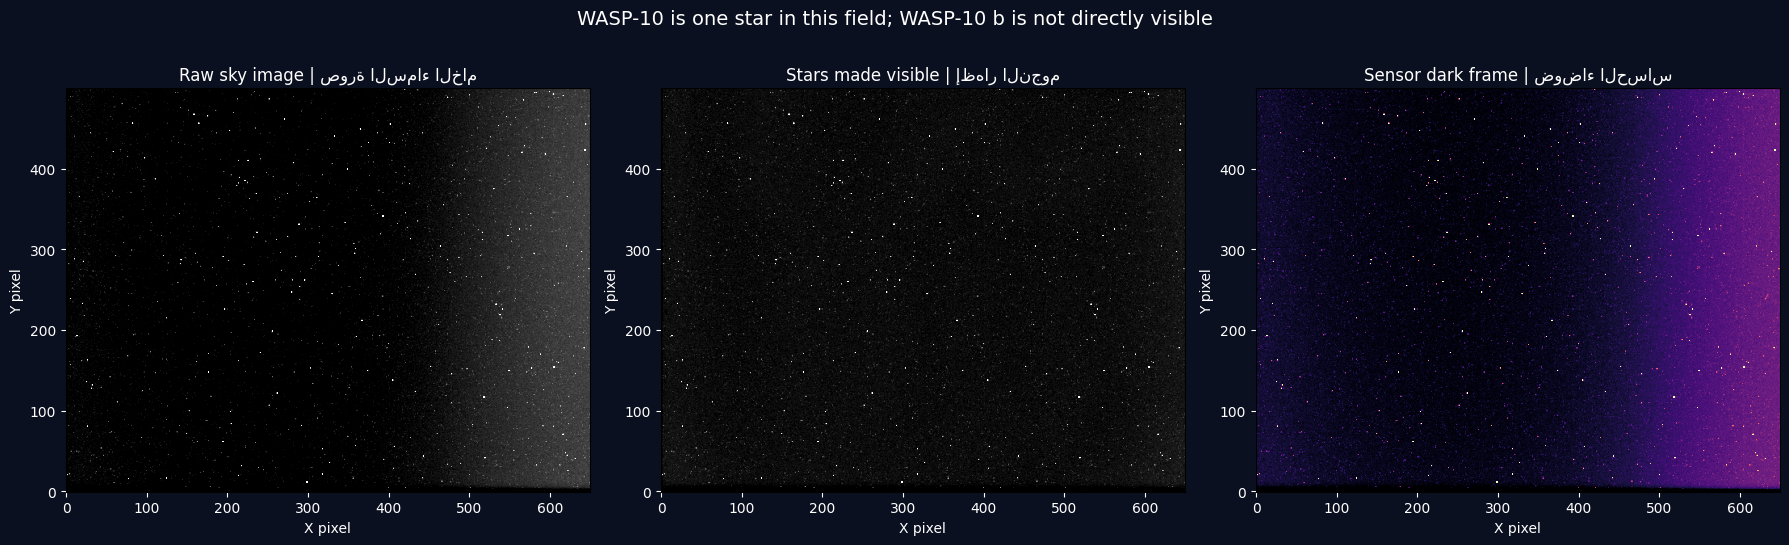

In [3]:
background = Background2D(
    science,
    box_size=(50, 50),
    filter_size=(3, 3),
    sigma_clip=SigmaClip(sigma=3),
    bkg_estimator=MedianBackground(),
).background
enhanced = science - background

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), facecolor='#0b1020')
axes[0].imshow(
    science, cmap='gray', origin='lower',
    vmin=np.percentile(science, 50), vmax=np.percentile(science, 99.9),
)
axes[0].set_title('Raw sky image | صورة السماء الخام', color='white')
axes[1].imshow(
    enhanced, cmap='gray', origin='lower',
    vmin=np.percentile(enhanced, 10), vmax=np.percentile(enhanced, 99.9),
)
axes[1].set_title('Stars made visible | إظهار النجوم', color='white')
axes[2].imshow(
    dark, cmap='magma', origin='lower',
    vmin=np.percentile(dark, 5), vmax=np.percentile(dark, 99.9),
)
axes[2].set_title('Sensor dark frame | ضوضاء الحساس', color='white')
for axis in axes:
    axis.set_facecolor('black')
    axis.tick_params(colors='white')
    axis.set_xlabel('X pixel', color='white')
    axis.set_ylabel('Y pixel', color='white')
fig.suptitle('WASP-10 is one star in this field; WASP-10 b is not directly visible', color='white', fontsize=14)
plt.tight_layout();

### Important | مهم

This notebook deliberately does **not** circle WASP-10. Identifying it requires the next step: solving the sky coordinates or validating the target position with EXOTIC. Guessing the brightest point would be scientifically dishonest.

لا نضع دائرة حول WASP-10 تخميناً. سنحدد موقعه علمياً في الخطوة التالية باستخدام إحداثيات السماء أو EXOTIC.

## What the website user will see | ماذا سيرى مستخدم الموقع؟

The user will not see a FITS matrix or notebook. The website will present: enhanced image -> target star -> brightness over time -> transit-shaped dip -> evidence and limitations.